In [8]:
from sklearn.datasets import load_iris
iris =load_iris()

import pandas as pd
x = pd.DataFrame(iris.data, columns=iris.feature_names)
x.head()
y =pd.Series(iris.target)
df = x.copy()
df["target"] = y
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Visulalizing Dataset

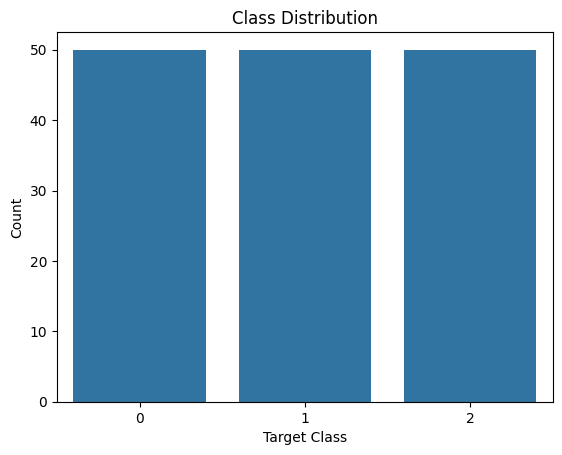

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# sns.countplot(x=iris.target)
sns.countplot(x = df['target'])
plt.title('Class Distribution')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.show()

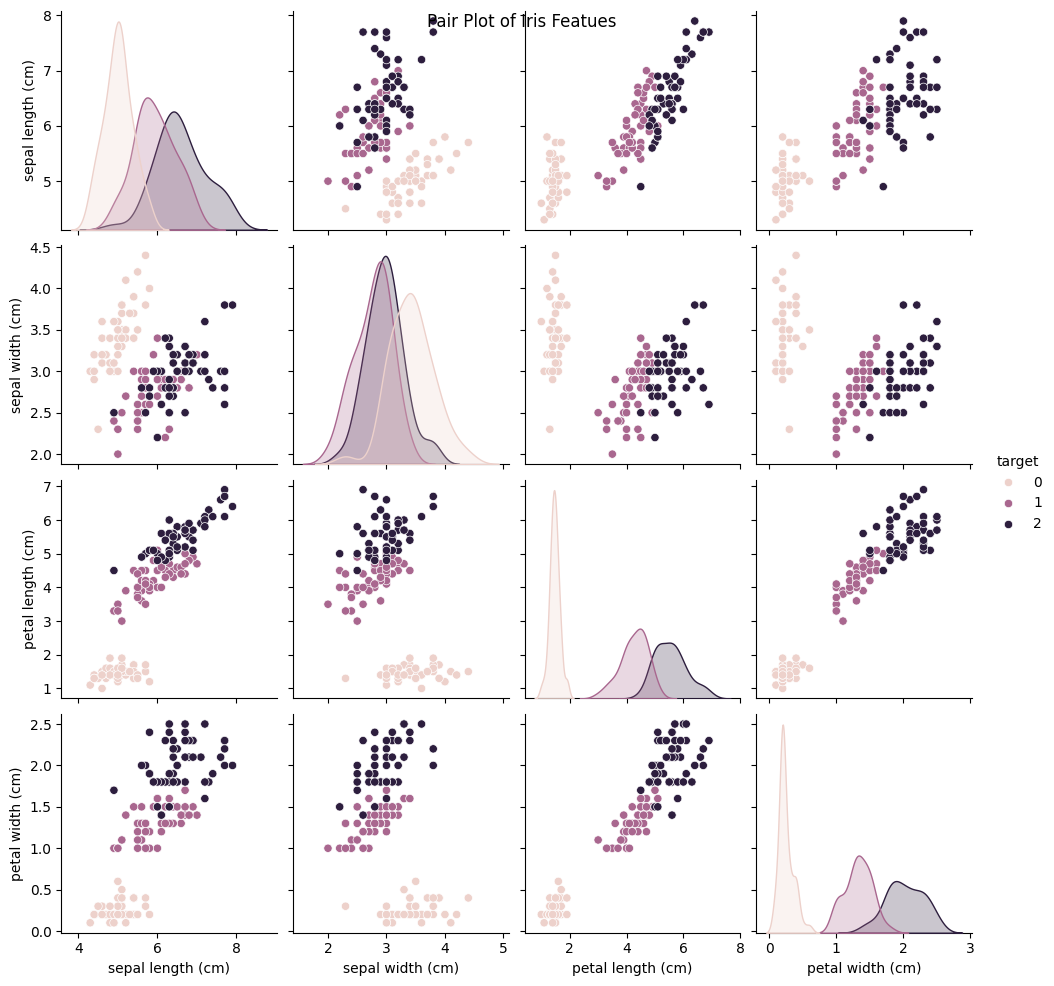

In [17]:
#sns.pairplot(df)
sns.pairplot(df, hue = 'target')
plt.suptitle("Pair Plot of Iris Featues")
plt.show()

Corelation HeatMap


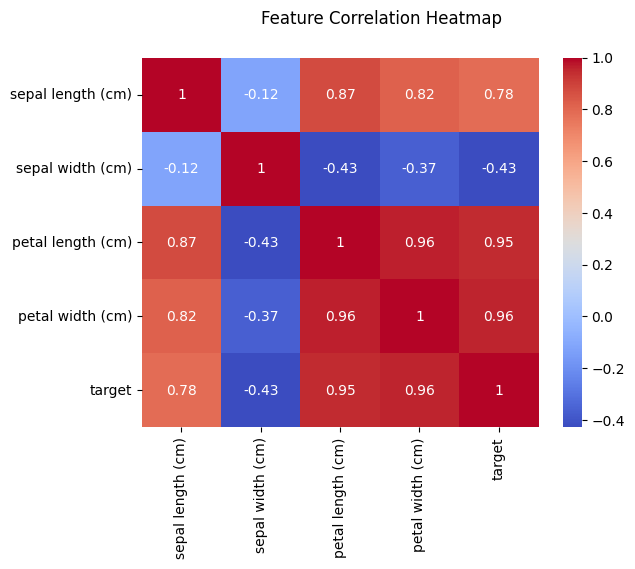

In [21]:
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.suptitle("Feature Correlation Heatmap")
plt.show()

Data PreProcessing

In [28]:
#Data splitting

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=42)


In [31]:
# Scale the feature
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)



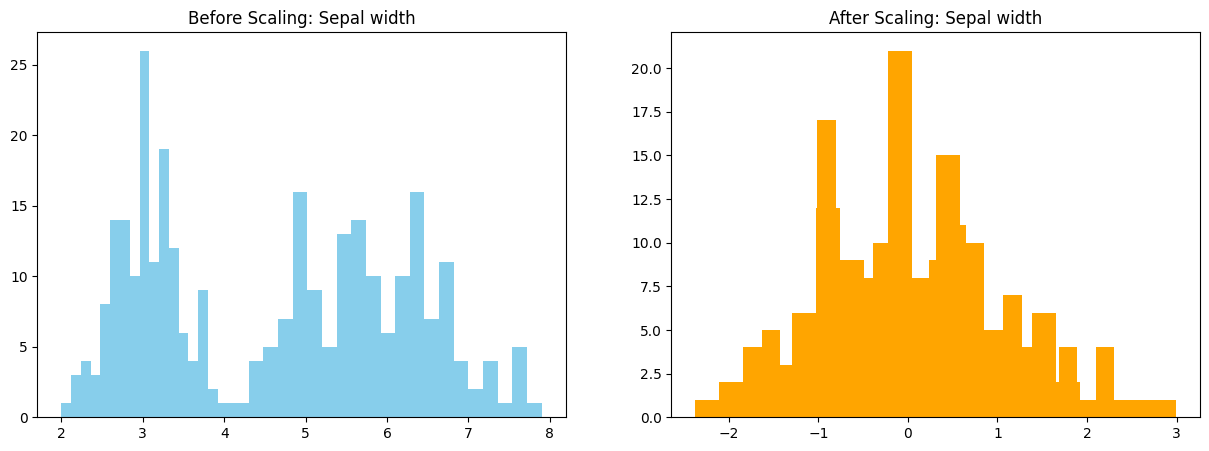

In [46]:
# Visualize Feature Distributions (Before and After scaling)

import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].hist(x.iloc[:, 0], bins = 20, color= "skyblue")
ax[0].set_title("Before Scaling: Sepal Length")

ax[1].hist(x_train[:,0],bins = 20, color= "orange")
ax[1].set_title("After Scaling: Sepal Length")


# ax[0].hist(x.iloc[:, 1], bins = 20, color= "skyblue")
# ax[0].set_title("Before Scaling: Sepal width")

# ax[1].hist(x_train[:,1],bins = 20, color= "orange")
# ax[1].set_title("After Scaling: Sepal width")
plt.show()

K-Nearest Neighbour(KNN)


In [47]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train,y_train)
y_pred = knn.predict(x_test)

Decision Trees


In [49]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier()
tree.fit(x_train,y_train)
y_pred_tree = tree.predict(x_test)

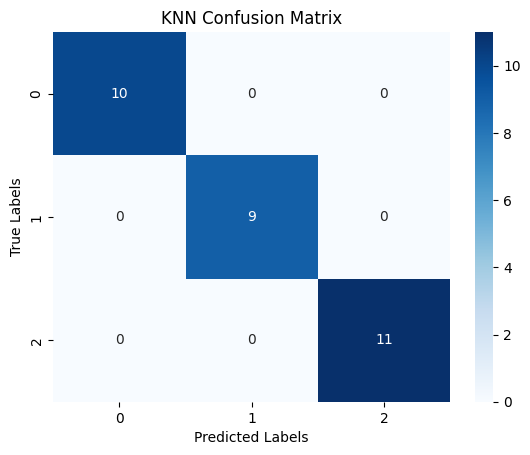

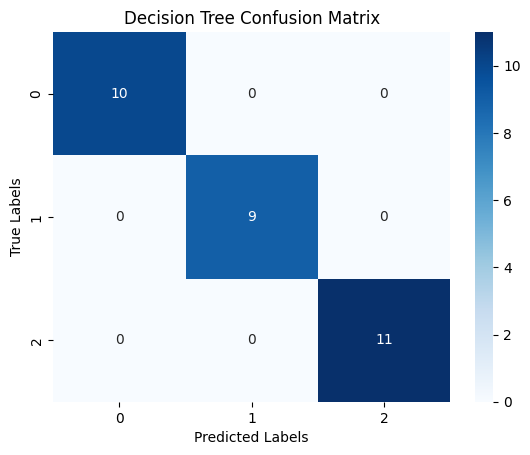

In [53]:
from sklearn.metrics import confusion_matrix, classification_report

def plot_confutions(y_true,y_pred,title):
  cm = confusion_matrix(y_true,y_pred)
  sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
  plt.xlabel('Predicted Labels')
  plt.ylabel('True Labels')
  plt.title(title)
  plt.show()

plot_confutions(y_test,y_pred,"KNN Confusion Matrix")
plot_confutions(y_test, y_pred_tree, "Decision Tree Confusion Matrix")




In [54]:
print("KNN Classification Report:")
print(classification_report(y_test,y_pred))
print("\n")
print("Decision Tree Classification Report:")
print(classification_report(y_test,y_pred_tree))


KNN Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

